# PS-S06E06: XGBoost

This notebook tackles the [**Playground Series – Season 6, Episode 7: Predicting Student Health Risk**](https://www.kaggle.com/competitions/playground-series-s6e7), a competition focused on predicting a class label (`at-risk`, `unhealthy`, and `fit`) for the `health_condition` target, based on features describing sleep, heart rate, BMI, physical activity, and other lifestyle behaviors for each student.

## Introduction

**XGBoost** is well-suited to this tabular classification task. It handles the mix of numerical lifestyle indicators (like BMI, steps, and heart rate) and categorical variables (like `stress_level`, `sleep_quality`) natively via , includes L1/L2 regularization to prevent overfitting, and pairs well with  to maintain class balance across folds.

The target is a three-class problem (`at-risk`, `unhealthy`, and `fit`), evaluated by **Balanced Accuracy** to account for any class imbalance. Categorical features are ordinal- or unordered-encoded in the  and passed as  dtype directly to XGBoost.

This notebook is one of several exploring different models for this challenge. The EDA was performed in: [**PS-S06E07: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e07-eda).

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, balanced_accuracy_score
from sklearn.feature_selection import RFECV
from sklearn.utils.class_weight import compute_sample_weight

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e07_feature_engineering import FeatureFactory
from ps_s06e07_model_visualizer import ModelVisualizer
from ps_s06e07_experiment_setup import ExperimentSetup

# Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='XGBoost',
    use_gpu=True,
    perform_rfe=False,
    perform_optuna_tuning=True
)

# Get the seed, and apply it to all the internals like pandas and numpy
seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

# The target feature
TARGET = 'health_condition'

# Class label mapping  (must be consistent everywhere)
target_mapping = {'at-risk': 0, 'unhealthy': 1, 'fit': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = setup.get_combined_training_data(include_original=False)
train_ids = training_df['id'].copy()

TRAINING DATASET

   id health_condition  sleep_duration  heart_rate    bmi  \
0   0        unhealthy           5.220      70.600 25.660   
1   1          at-risk           5.530      71.300 25.840   
2   2        unhealthy           5.290      75.400 24.540   
3   3        unhealthy           4.700      77.200 23.130   
4   4          at-risk           7.230      73.400 28.440   

   calorie_expenditure  step_count  exercise_duration  water_intake diet_type  \
0            2,174.000   1,326.000             19.800         1.860       veg   
1            1,966.000   9,891.000             49.900         1.260   non-veg   
2            2,688.000  14,216.000             38.100         1.600       veg   
3            2,630.000   7,174.000             59.900         2.020       veg   
4            2,560.000   6,584.000             46.000         2.250       veg   

  stress_level sleep_quality physical_activity_level smoking_alcohol  gender  \
0         high       average               seden

In [4]:
test_df = setup.read_dataset('test')
test_ids  = test_df['id'].copy()

TEST DATASET

       id  sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0  690088           5.350      64.900 23.480            2,745.000  14,167.000   
1  690089             NaN      83.100 22.420            1,773.000   6,801.000   
2  690090           6.680      59.700 24.140            3,040.000  13,250.000   
3  690091           7.130      78.500 26.260            2,494.000   6,331.000   
4  690092           5.490      77.700 23.290            1,828.000  13,894.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             59.500         1.860       veg         high          poor   
1             24.500         2.400  balanced         high          poor   
2             48.500         2.760  balanced       medium          poor   
3             56.900         2.340       veg          low          good   
4             39.400         2.450       veg         high       average   

  physical_activity_level smoking_alcohol gender

## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'encoding',
    'sleep_stress',
    'activity_energy',
    'bmi_features',
    'risk_score',
    'missing_flags',
    'numeric_expansion'
]

In [6]:
print('Performing initial feature engineering.')

# Encode target labels: at-risk=0, unhealthy=1, fit=2
y = training_df[TARGET].map(target_mapping).astype(int)

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 15
New Feature Count: 59
   sleep_duration  heart_rate    bmi  calorie_expenditure  step_count  \
0           5.220      70.600 25.660            2,174.000   1,326.000   
1           5.530      71.300 25.840            1,966.000   9,891.000   
2           5.290      75.400 24.540            2,688.000  14,216.000   
3           4.700      77.200 23.130            2,630.000   7,174.000   
4           7.230      73.400 28.440            2,560.000   6,584.000   

   exercise_duration  water_intake diet_type stress_level sleep_quality  \
0             19.800         1.860       veg         high       average   
1             49.900         1.260   non-veg          low       average   
2             38.100         1.600       veg         high          poor   
3             59.900         2.020       veg         high       average   
4             46.000         2.250       veg          NaN       average   

  physical_activity_level 

## Optional Recursive Feature Elimination and Optuna Training

If `perform_rfe` is `True` in `setup`, Recursive Feature Elimination with Cross-Validation (RFECV) is performed on a numeric-encoded snapshot of the feature-engineered training set. It iteratively removes the weakest feature and re-scores until the optimal subset is found. The selected feature names are then applied per-fold during training to prevent leakage.

If `perform_optuna_tuning` is `True` in `setup`, an Optuna study maximizes Balanced Accuracy over the full 5-fold CV loop. Otherwise, a previously derived best-params dict is used directly.

In [7]:
n_jobs = 1 if setup.use_gpu() else os.cpu_count()

X_rfe = X.copy()

# Convert all object and category columns to integer codes for RFE
cat_cols_rfe = X_rfe.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_rfe:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes
    
rfe_filename = 'selected_features_xgb.json'

if setup.perform_rfe():
    warnings.filterwarnings('ignore', category=UserWarning, module='xgboost.core')

    # Enable metadata routing globally
    sklearn.set_config(enable_metadata_routing=True)

    clf = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        tree_method='hist',
        enable_categorical=True,
        device='cuda' if setup.use_gpu() else 'cpu',
        objective='multi:softprob',
        num_class=3,
        random_state=seed,
        n_jobs=1
    )

    # Tell the classifier to accept sample_weight during fit
    clf.set_fit_request(sample_weight=True)
    
    # Wrap the scorer and tell it to ignore sample_weight during evaluation
    scorer = make_scorer(balanced_accuracy_score)
    scorer.set_score_request(sample_weight=False)

    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=seed),
        scoring=scorer,
        min_features_to_select=10,
        n_jobs=n_jobs,
        verbose=1
    )
    
    # Compute and pass the balanced sample weights for the full target
    sample_weight_full = compute_sample_weight('balanced', y)

    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    rfecv.fit(X_rfe, y, sample_weight=sample_weight_full)

    print(f'Optimal number of features: {rfecv.n_features_}')

    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross-validation score (Balanced Accuracy)')
    plt.plot(
        range(rfecv.min_features_to_select,
              len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
        rfecv.cv_results_['mean_test_score']
    )
    plt.title('RFE Performance for Student Health Risk')
    plt.show()

    optimal_cols = X_rfe.columns[rfecv.support_]
    
    setup.save_rfe(rfe_filename, optimal_cols)
else:
    optimal_cols = setup.load_rfe(rfe_filename, X)
    
    # If the file is empty, use all of the columns
    if len(optimal_cols) == 0:
        print('\nUsing all features')
        optimal_cols = X.columns
        
print('\nOptimal Features Count:', len(optimal_cols))

Loaded 23 features from selected_features_xgb.json

Optimal Features Count: 23


In [8]:
print("Precomputing fold-wise FE and QuantileDMatrix objects for Optuna and/or training (once)...")
skf_cache = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
fold_fe = []

# Only split on competition rows; original rows always go to train
comp_mask = training_df['is_original'] == False
comp_idx = np.where(comp_mask)[0]

for fold, (rel_train_idx, rel_val_idx) in enumerate(skf_cache.split(comp_idx, y.iloc[comp_idx])):
    train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
    val_idx = comp_idx[rel_val_idx]
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold   = X.iloc[val_idx]
    y_val_fold   = y.iloc[val_idx]

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)

    final_cols = [c for c in list(optimal_cols) if c in X_train_trans.columns]
    X_train_trans = X_train_trans[final_cols]
    X_val_trans   = X_val_trans[final_cols]

    # Convert any booleans to integers (0 and 1)
    bool_cols = X_train_trans.select_dtypes(include=['bool']).columns.tolist()
    for col in bool_cols:
        X_train_trans[col] = X_train_trans[col].astype(int)
        X_val_trans[col]   = X_val_trans[col].astype(int)

    # Convert remaining text/objects to category
    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')

    # Give competition rows 3× the weight of original rows
    source_weights = np.where(training_df['is_original'].iloc[train_idx], 1.0, 3.0)
    class_weights  = compute_sample_weight('balanced', y_train_fold)
    weights        = source_weights * class_weights

    # Build the quantile-sketch / histogram index ONCE per fold.
    dtrain = xgb.QuantileDMatrix(
        X_train_trans, label=y_train_fold, weight=weights, enable_categorical=True
    )
    # ref=dtrain reuses dtrain's bin boundaries instead of re-sketching.
    dval = xgb.QuantileDMatrix(
        X_val_trans, label=y_val_fold, ref=dtrain, enable_categorical=True
    )

    fold_fe.append(fe)
    fold_cache.append((dtrain, dval, y_train_fold, y_val_fold, val_idx, final_cols, cat_cols))

print(f"Cached {len(fold_cache)} folds.")

Precomputing fold-wise FE and QuantileDMatrix objects for Optuna and/or training (once)...
Cached 5 folds.


In [9]:
def balanced_accuracy_xgb_fast(arg1, arg2):
    # Robust to either XGBoost custom_metric calling convention:
    # legacy feval style: (y_pred, dtrain)  |  newer style: (y_true, y_pred)
    if hasattr(arg2, 'get_label'):
        y_pred, dtrain = arg1, arg2
        y_true = dtrain.get_label().astype(np.int64)
    else:
        y_true, y_pred = arg1, arg2
        y_true = y_true.astype(np.int64)

    n_samples = len(y_true)
    n_classes = 3
    preds = np.asarray(y_pred).reshape(n_samples, n_classes).argmax(axis=1)

    cm = np.bincount(
        y_true * n_classes + preds, minlength=n_classes * n_classes
    ).reshape(n_classes, n_classes)
    row_sums = cm.sum(axis=1)
    recalls = np.divide(
        np.diag(cm), row_sums,
        out=np.zeros(n_classes, dtype=float), where=row_sums != 0
    )
    return 'balanced_accuracy', recalls.mean()

In [10]:
def objective(trial):
    n_estimators = 3000
    
    params = {
        # Core booster params
        'learning_rate': trial.suggest_float('learning_rate', 0.015, 0.08, log=True),
        'min_child_weight': trial.suggest_float('min_child_weight', 20.0, 150.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.70, 0.90),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.50, 0.85),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 0.9),
        'max_leaves': trial.suggest_int('max_leaves', 15, 96),
        'max_depth': 0, # remove the depth limit and allow max_leaves to control the tree growth entirely
        # Regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.0, 3.0),

        # Tree structure
        'grow_policy': 'lossguide',

        # Boilerplate
        'objective': 'multi:softprob',
        'num_class': 3,
        'tree_method': 'hist',
        'device': 'cuda' if setup.use_gpu() else 'cpu',
        'random_state': seed,
        'n_jobs': n_jobs
    }

    oof_preds = np.full(len(y), -1, dtype=int)   # -1 sentinel to catch unfilled slots

    for fold, (dtrain, dval, y_train_fold, y_val_fold, val_idx, final_cols, cat_cols) in enumerate(fold_cache):
        fold_start = time.perf_counter()

        booster = xgb.train(
            params,
            dtrain,
            num_boost_round=n_estimators,
            evals=[(dval, 'validation_0')],
            custom_metric=balanced_accuracy_xgb_fast,
            early_stopping_rounds=200,
            maximize=True,
            verbose_eval=False,
        )

        fold_elapsed = time.perf_counter() - fold_start
        n_trees = booster.num_boosted_rounds()

        probs = booster.predict(dval, iteration_range=(0, booster.best_iteration + 1))
        preds = probs.argmax(axis=1)
        oof_preds[val_idx] = preds
        fold_score = balanced_accuracy_score(y_val_fold, preds)
        
        print(f'  Fold {fold+1}: {fold_elapsed:6.1f}s | trees={n_trees:5d} '
              f'| {fold_elapsed/n_trees*1000:6.2f} ms/tree | bal_acc={fold_score:.5f}')

        trial.report(fold_score, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    # Only score the rows that were actually predicted (val_idx covered rows)
    filled_mask = oof_preds >= 0
    return balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])

In [11]:
# Load the "best" parameters that were calculated in an earlier Optuna run
optuna_filename = 'optuna_params_xgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning() or len(best_params) == 0:
    print('Starting XGBoost Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=3,
        interval_steps=1,
    )

    study_xgb = optuna.create_study(
        storage='sqlite:///xgb_study.db',
        load_if_exists=True,
        direction='maximize',
        study_name='xgb_predict_student_health_risk_optuna',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True,       # models parameter correlations — helps here since
        )                            # lambda/mcw/lr are correlated in the best trials
    )
    
    # Seed with current best so trial 0 isn't cold-start
    if len(study_xgb.trials) == 0:
        study_xgb.enqueue_trial(best_params)

    study_xgb.optimize(
        objective,
        n_trials=50,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )

    print('Best Trial:')
    print(f'   Balanced Accuracy: {study_xgb.best_value:.5f}')
    print('   Params: ', study_xgb.best_params)

    best_params = study_xgb.best_params
    
    setup.save_optuna_params(optuna_filename, best_params)
else:
    print('Using placeholder params:')
    print('  Params: ', best_params)

Loaded 9 parameters from optuna_params_xgb.json
Starting XGBoost Optuna Optimization...


[I 2026-07-10 15:38:13,705] Using an existing study with name 'xgb_predict_student_health_risk_optuna' instead of creating a new one.


  0%|          | 0/50 [00:00<?, ?it/s]

  Fold 1:   17.7s | trees=  872 |  20.30 ms/tree | bal_acc=0.95088
  Fold 2:   13.7s | trees=  666 |  20.52 ms/tree | bal_acc=0.95048
  Fold 3:   13.7s | trees=  665 |  20.55 ms/tree | bal_acc=0.95078
  Fold 4:   32.5s | trees= 1637 |  19.87 ms/tree | bal_acc=0.95015
  Fold 5:   16.8s | trees=  817 |  20.56 ms/tree | bal_acc=0.94783
[I 2026-07-10 15:39:49,008] Trial 52 finished with value: 0.9500240589850355 and parameters: {'learning_rate': 0.031181802984340413, 'min_child_weight': 41.82802787150099, 'subsample': 0.8659156386616549, 'colsample_bytree': 0.8280956997527334, 'colsample_bylevel': 0.7761168202738431, 'max_leaves': 15, 'reg_alpha': 0.019353877424547198, 'reg_lambda': 9.51365639359175, 'gamma': 2.9122809930631792}. Best is trial 0 with value: 0.9500827995564439.
  Fold 1:   28.3s | trees= 1293 |  21.89 ms/tree | bal_acc=0.95076
  Fold 2:   20.3s | trees=  903 |  22.44 ms/tree | bal_acc=0.95046
  Fold 3:   16.9s | trees=  744 |  22.67 ms/tree | bal_acc=0.95069
  Fold 4:   14.

## Model Training

In [12]:
xgb_tuned_params = {
    **best_params,
    'objective': 'multi:softprob',
    'num_class': 3,
    'max_depth': 0,    # remove the depth limit and allow max_leaves to control the tree growth entirely
    'grow_policy': 'lossguide',
    'n_jobs': n_jobs,
    'tree_method': 'hist',
    'device': 'cuda' if setup.use_gpu() else 'cpu',
}

n_estimators_final = 6000

print('Final XGBoost CV Training with 5-Seed Averaging')
print('=======================================================')
print('Parameters used for training:')
print(xgb_tuned_params)

seeds = setup.seed()

eval_results = []
models = []

oof_probs_all = np.zeros((len(y), 3), dtype=np.float64)
test_probs_all = np.zeros((len(test_df), 3), dtype=np.float64)

for s_idx, current_seed in enumerate(seeds):
    print(f'\n' + '='*60)
    print(f'SEED RUN {s_idx + 1}/{len(seeds)}: seed={current_seed}')
    print('='*60)
    setup.set_seeds(current_seed)

    # 1. Recompute folds and features for this seed
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    
    # Only split on competition rows; original rows always go to train
    comp_mask = training_df['is_original'] == False
    comp_idx = np.where(comp_mask)[0]
    
    seed_fold_cache = []
    seed_fold_fe = []
    
    for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y.iloc[comp_idx])):
        train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
        val_idx = comp_idx[rel_val_idx]
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold   = X.iloc[val_idx]
        y_val_fold   = y.iloc[val_idx]

        fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=current_seed)
        X_train_trans = fe.fit_transform(X_train_fold)
        X_val_trans   = fe.transform(X_val_fold)

        final_cols = [c for c in list(optimal_cols) if c in X_train_trans.columns]
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]

        # Convert any booleans to integers (0 and 1)
        bool_cols = X_train_trans.select_dtypes(include=['bool']).columns.tolist()
        for col in bool_cols:
            X_train_trans[col] = X_train_trans[col].astype(int)
            X_val_trans[col]   = X_val_trans[col].astype(int)

        # Convert remaining text/objects to category
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
        for col in cat_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col]   = X_val_trans[col].astype('category')

        # Give competition rows 3× the weight of original rows
        # Give all rows equal source weighting
        class_weights  = compute_sample_weight('balanced', y_train_fold)
        weights        = class_weights

        # Build the quantile-sketch / histogram index ONCE per fold.
        dtrain = xgb.QuantileDMatrix(
            X_train_trans, label=y_train_fold, weight=weights, enable_categorical=True
        )
        dval = xgb.QuantileDMatrix(
            X_val_trans, label=y_val_fold, ref=dtrain, enable_categorical=True
        )

        seed_fold_fe.append(fe)
        seed_fold_cache.append((dtrain, dval, y_train_fold, y_val_fold, val_idx, final_cols, cat_cols))

    # 2. Update params for this seed
    current_xgb_params = {
        **xgb_tuned_params,
        'random_state': current_seed
    }
    
    # 3. Train models for this seed
    oof_probs_seed = np.zeros((len(y), 3), dtype=np.float64)
    oof_preds_seed = np.full(len(y), -1, dtype=np.int32)
    test_probs_seed = np.zeros((len(test_df), 3), dtype=np.float64)
    
    for fold, (dtrain, dval, y_train_fold, y_val_fold, val_idx, final_cols, cat_cols) in enumerate(seed_fold_cache):
        print(f'Starting fold {fold+1}/5 for seed {current_seed}...')

        X_test_trans  = seed_fold_fe[fold].transform(test_df)

        for col in final_cols:
            if col not in X_test_trans.columns:
                X_test_trans[col] = 0

        X_test_trans  = X_test_trans[final_cols]
        for col in cat_cols:
            X_test_trans[col] = X_test_trans[col].astype('category')

        dtest = xgb.QuantileDMatrix(X_test_trans, ref=dtrain, enable_categorical=True)

        fold_eval_result = {}
        booster = xgb.train(
            current_xgb_params,
            dtrain,
            num_boost_round=n_estimators_final,
            evals=[(dval, 'validation_0')],
            custom_metric=balanced_accuracy_xgb_fast,
            early_stopping_rounds=200,
            maximize=True,
            evals_result=fold_eval_result,
            verbose_eval=500,
        )

        eval_results.append(fold_eval_result)
        models.append(booster)

        probs = booster.predict(dval, iteration_range=(0, booster.best_iteration + 1))
        preds = probs.argmax(axis=1)

        oof_probs_seed[val_idx] = probs
        oof_preds_seed[val_idx] = preds

        fold_score = balanced_accuracy_score(y_val_fold, preds)
        n_trees = booster.num_boosted_rounds()
        print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f} (trees={n_trees})')

        test_probs_seed += booster.predict(dtest, iteration_range=(0, booster.best_iteration + 1)) / 5.0

        del booster
        gc.collect()

    filled_mask_seed = oof_preds_seed >= 0
    seed_score = balanced_accuracy_score(y[filled_mask_seed], oof_preds_seed[filled_mask_seed])
    print(f'--- Seed {current_seed} CV Balanced Accuracy: {seed_score:.6f} ---')

    oof_probs_all += oof_probs_seed
    test_probs_all += test_probs_seed

oof_probs = oof_probs_all / len(seeds)
test_probs = test_probs_all / len(seeds)

oof_preds = np.argmax(oof_probs, axis=1)
filled_mask = oof_preds >= 0
overall_score = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])

print('\n' + '='*60)
print(f'Seed-Averaged CV Balanced Accuracy: {overall_score:.6f}')
print('='*60)


Final XGBoost CV Training with 5-Seed Averaging
Parameters used for training:
{'learning_rate': 0.02993498721816477, 'min_child_weight': 30.41268734802772, 'subsample': 0.8689831375628863, 'colsample_bytree': 0.8051267331784174, 'colsample_bylevel': 0.881675614641526, 'max_leaves': 62, 'reg_alpha': 0.023572529099644912, 'reg_lambda': 0.7974009959597674, 'gamma': 2.2000309676829866, 'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 0, 'grow_policy': 'lossguide', 'n_jobs': 1, 'tree_method': 'hist', 'device': 'cuda'}

SEED RUN 1/5: seed=10301
Random seed set to: 10301
Starting fold 1/5 for seed 10301...
[0]	validation_0-mlogloss:1.06234	validation_0-balanced_accuracy:0.94734
[500]	validation_0-mlogloss:0.17364	validation_0-balanced_accuracy:0.95071
[565]	validation_0-mlogloss:0.17159	validation_0-balanced_accuracy:0.95064
Fold 1 Balanced Accuracy: 0.950890 (trees=566)
Starting fold 2/5 for seed 10301...
[0]	validation_0-mlogloss:1.06228	validation_0-balanced_accuracy:0.94605
[50

## Visualizing Model Performance
Four plots diagnose the health of the trained classifier.

### Learning Curves (Train vs. Validation Log-Loss)
This plot shows  over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Early stopping terminates training once the validation loss plateaus.

In [13]:
mviz = ModelVisualizer(model_name='XGBoost')

# Handle case when training metrics are not in eval_results to avoid KeyError
for res in eval_results:
    if 'validation_1' not in res:
        res['validation_1'] = {'mlogloss': []}

### Feature Importance
This bar chart ranks features by average gain across all folds.
* **Validation check:** lifestyle and body indicators like `bmi`, `sleep_duration`, `step_count`, `stress_level`, `exercise_duration` should dominate. If none of these appear near the top, something is wrong upstream.
* **Feature check:** interaction features like `lifestyle_risk_score`, `sleep_quality_index`, and `calories_per_step` should rank highly if their corresponding strategies are active in `fe_strategies`.
* **Leakage check:** `id` must not appear in the chart at all.

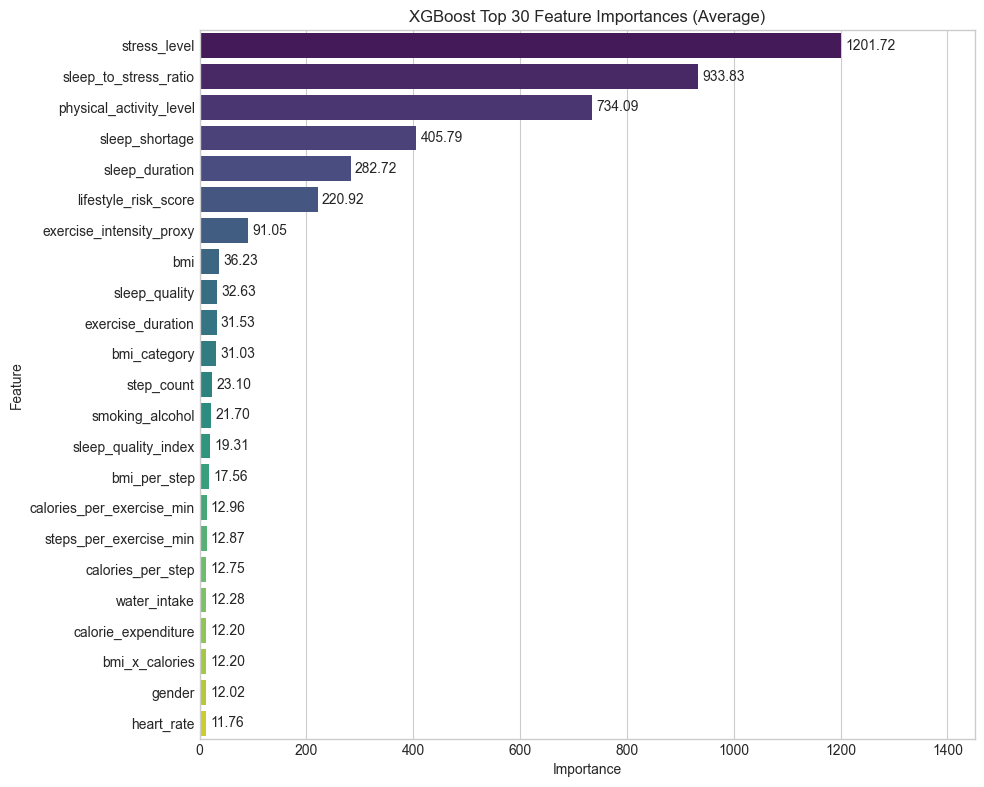

In [14]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Overlays the distribution of true class labels against OOF predicted labels (integer-encoded: at-risk=0, unhealthy=1, fit=2). A large divergence on one class suggests the model is systematically misclassifying that health condition.

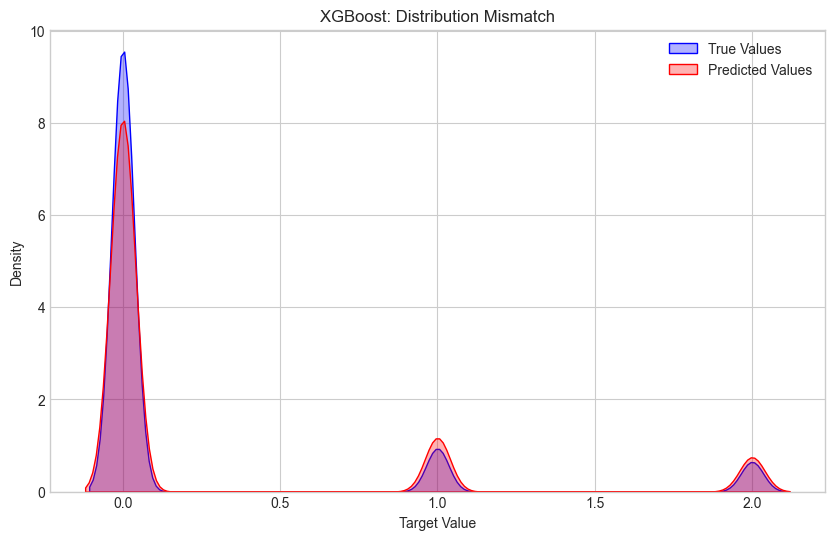

In [15]:
mviz.plot_distribution_mismatch(y_true=y[filled_mask], y_preds=oof_preds[filled_mask])

### Confusion Matrix
A normalized confusion matrix across the three target health classes.
* **Diagonal:** Correct classifications for each class. All three should be high.
* **at-risk column (0):** at-risk cases represent students with severe health risk behaviors; off-diagonal entries here are the most critical failures to monitor.
* **unhealthy row (1):** unhealthy cases represent moderate risks; off-diagonal values between unhealthy and at-risk are common due to overlapping behavior metrics.

Normalized confusion matrix


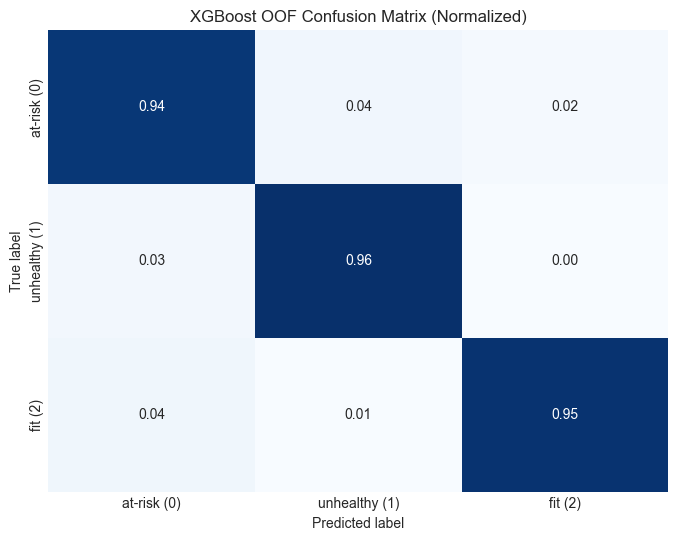

In [16]:
y_pred_class = np.argmax(oof_probs, axis=1)

mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=y_pred_class[filled_mask],
    classes=['at-risk (0)', 'unhealthy (1)', 'fit (2)'],
    normalize=True,
    title='XGBoost OOF Confusion Matrix (Normalized)'
)

### Multiclass ROC Curve (One-vs-Rest)
Each class is treated as the positive class in turn. The AUC for each curve measures how well the model separates that class from the other two. All three curves should sit well above the diagonal; a sagging at-risk or unhealthy curve indicates a struggle to separate the specific risk levels.

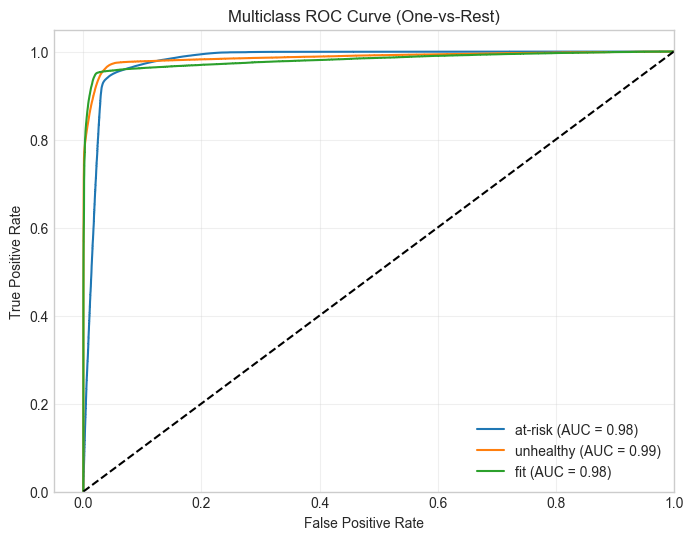

In [17]:
mviz.plot_multiclass_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask])

## Prepare Submission

The competition requires the hard predicted class label (, , or ) for each row in the test set. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [18]:
submission_df = setup.read_dataset('submission')

numeric_preds = np.argmax(test_probs, axis=1)

# Map numeric predictions back to string class labels
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))

SAMPLE SUBMISSION


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
5,690093,fit
6,690094,at-risk
7,690095,at-risk
8,690096,at-risk
9,690097,at-risk


In [19]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

Out-of-fold (OOF) and averaged test-set probabilities are saved for downstream ensembling (blending or stacking).

For this three-class task we save the full probability distribution across , , and  rather than just the argmax labels. Raw probabilities are essential for:

- **Weighted Blending**: Averaging confidence scores across XGBoost, LightGBM, and CatBoost models.
- **Stacking**: Using these probabilities as meta-features for a secondary model.
- **Calibration Analysis**: Verifying that predicted confidence aligns with actual class frequencies.

In [20]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: at-risk=0, unhealthy=1, fit=2
prob_cols = ['prob_at_risk', 'prob_unhealthy', 'prob_fit']

# OOF probabilities
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_df = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y.values}),
    oof_prob_df
], axis=1)
oof_df = oof_df[filled_mask]
oof_df.to_csv(f'{output_dir}/xgb_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/xgb_test_probs.csv', index=False)

print(f'Saved for ensembling: {output_dir}/xgb_oof_probs.csv {output_dir}/xgb_test_probs.csv')

Saved for ensembling: predictions/xgb_oof_probs.csv predictions/xgb_test_probs.csv
